<a href="https://colab.research.google.com/github/aleakucing/Pembelajaran-Memsin/blob/main/KUIS1/KUIS1_244107020062_Muchammad_Ibrahim_Al_Amin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pengantar

Pada Kuis 1 ini Anda diminta untuk melakukan proses explorartory data analysis (EDA) dan pra pengolahan data pada dataset "Census Income". Dataset ini merupakan data tabular yang memiliki beberapa nilai yang hilang (missing value) dan nama variabel (fitur) yang perlu disesuaikan.

Untuk membantu Anda, notebook ini akan memberikan kode awal untuk proses download data, load data, dan inspeksi informasi terkait dengan metadata.

# Load Data and Inspect Metadata

In [1]:
# Install UCI REPO Library
!pip install -q ucimlrepo

In [2]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [3]:
# fetch data
adult_income = fetch_ucirepo(id=2)

In [4]:
# Data
X = adult_income.data.features
y = adult_income.data.targets

# Concate Features and Target
df = pd.concat([X, y], axis=1)

# Show Top 5
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
# Data Size
df.shape

(48842, 15)

In [6]:
# Inspect metadata
adult_income.metadata

{'uci_id': 2,
 'name': 'Adult',
 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult',
 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv',
 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ',
 'area': 'Social Science',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 48842,
 'num_features': 14,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'],
 'target_col': ['income'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1996,
 'last_updated': 'Tue Sep 24 2024',
 'dataset_doi': '10.24432/C5XW20',
 'creators': ['Barry Becker', 'Ronny Kohavi'],
 'intro_paper': None,
 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was ex

# Bagian 1 - Data Loading dan Data Imputation

## Soal 1 (5 poin)
1.   Lakukan inspeksi profile data
2.   **Variabel apa** yang memiliki **nilai yang hilang** (missing value) dan **berapa** jumlahnya?



In [8]:
# Jawab Soal 1
# Kerjakan pada cell ini
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


,0
age,0
workclass,963
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,966
relationship,0
race,0
sex,0


## Soal 2 (5 poin)
1. Lakukan proses data imputation pada fitur yang memiliki data yang hilang
2. Cek kembali apakah masih terdapat data yang hilang

In [9]:
# Jawab Soal 2
# Kerjakan pada cell ini
df['workclass'].fillna(value=df['workclass'].mode()[0], inplace=True)
df['occupation'].fillna(value=df['occupation'].mode()[0], inplace=True)
df['native-country'].fillna(value=df['native-country'].mode()[0], inplace=True)

# 2. Cek kembali apakah masih terdapat data yang hilang
df.isnull().sum()
# Anda diperbolehkan menambah cell jika diperlukan

/tmp/ipykernel_2585/3975827987.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['workclass'].fillna(value=df['workclass'].mode()[0], inplace=True)
/tmp/ipykernel_2585/3975827987.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value,

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


## Soal 3 (10 poin)
Inspeksi semua fitur kualitatif. Jika terdapat value yang **tidak sesuai**, **ganti dengan 'Others'** atau yang sesuai atau jika terdapat duplikasi karena **kesalahan penulisan**, lakukan penyesuaian.

In [14]:
# Jawab Soal 3
# Kerjakan pada cell ini
print(df['workclass'].unique())
print(df['occupation'].unique())
print(df['native-country'].unique())
print(df['income'].unique())


['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov'
 'Others' 'Self-emp-inc' 'Without-pay' 'Never-worked']
['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' 'Others'
 'Protective-serv' 'Armed-Forces' 'Priv-house-serv']
['United-States' 'Cuba' 'Jamaica' 'India' 'Others' 'Mexico' 'South'
 'Puerto-Rico' 'Honduras' 'England' 'Canada' 'Germany' 'Iran'
 'Philippines' 'Italy' 'Poland' 'Colombia' 'Cambodia' 'Thailand' 'Ecuador'
 'Laos' 'Taiwan' 'Haiti' 'Portugal' 'Dominican-Republic' 'El-Salvador'
 'France' 'Guatemala' 'China' 'Japan' 'Yugoslavia' 'Peru' 'Scotland'
 'Trinadad&Tobago' 'Greece' 'Nicaragua' 'Vietnam' 'Hong Kong' 'Ireland'
 'Hungary' 'Holland-Netherlands']
['<=50K' '>50K']


In [16]:
df['workclass'] = df['workclass'].replace('?', 'Others')
df['occupation'] = df['occupation'].replace('?', 'Others')
df['native-country'] = df['native-country'].replace('?', 'Others')

df['native-country'] = df['native-country'].replace('Holand-Netherlands', 'Holland-Netherlands')
df['native-country'] = df['native-country'].replace('Columbia', 'Colombia')
df['native-country'] = df['native-country'].replace('Hong', 'Hong Kong')

df['income'] = df['income'].str.replace('.', '', regex=False)

print("\nHasil workclass:")
print(df['workclass'].unique())
print("\nHasil native-country:")
print(df['native-country'].unique())
print("\nHasil income:")
print(df['income'].unique())


Hasil workclass:
['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov'
 'Others' 'Self-emp-inc' 'Without-pay' 'Never-worked']

Hasil native-country:
['United-States' 'Cuba' 'Jamaica' 'India' 'Others' 'Mexico' 'South'
 'Puerto-Rico' 'Honduras' 'England' 'Canada' 'Germany' 'Iran'
 'Philippines' 'Italy' 'Poland' 'Colombia' 'Cambodia' 'Thailand' 'Ecuador'
 'Laos' 'Taiwan' 'Haiti' 'Portugal' 'Dominican-Republic' 'El-Salvador'
 'France' 'Guatemala' 'China' 'Japan' 'Yugoslavia' 'Peru' 'Scotland'
 'Trinadad&Tobago' 'Greece' 'Nicaragua' 'Vietnam' 'Hong Kong' 'Ireland'
 'Hungary' 'Holland-Netherlands']

Hasil income:
['<=50K' '>50K']


# Bagian 2 - Visual Inspection



## Soal 1 - Visualisasi Data (20 poin)
Lakukan inspeksi visual pada,
1. Pada kolom 'age' dengan menggunakan histrogram
2. Pada kolom 'education' education menggunakan barchart
3. Pada kolom 'income' terhadap 'hours_per_week' menggunakan boxplot (kelompokkan berdasarkan kelompok income)
4. Pada kolom 'age' terhadap 'capital-gain' dan 'capital-loss' dengan lineplot (1 lineplot 2 data)

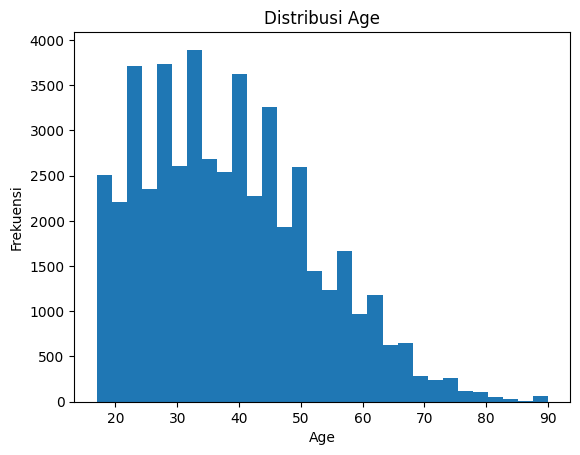

In [17]:
# Jawab 1.1 - Histrogram
plt.figure()
plt.hist(df['age'], bins=30)
plt.title('Distribusi Age')
plt.xlabel('Age'); plt.ylabel('Frekuensi')
plt.show()

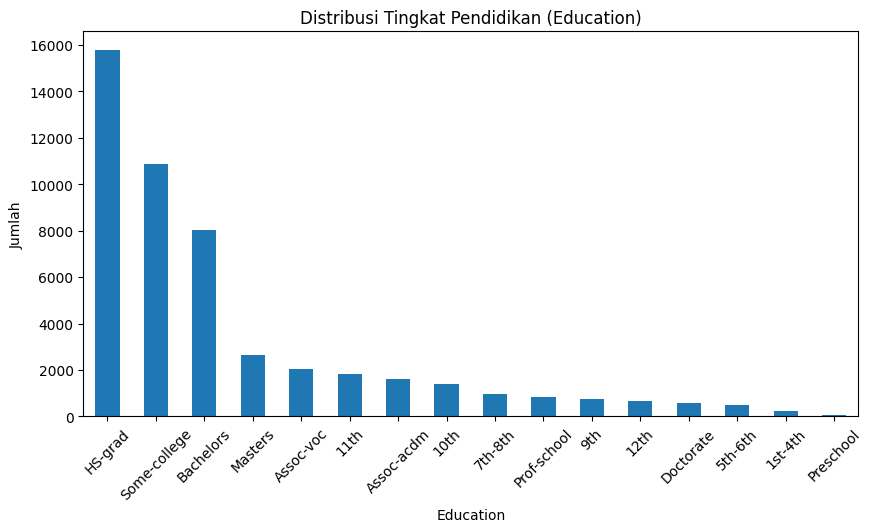

In [18]:
# Jawab 1.2 - Barchart
plt.figure(figsize=(10, 5))
df['education'].value_counts().plot(kind='bar')
plt.title('Distribusi Tingkat Pendidikan (Education)')
plt.xlabel('Education')
plt.ylabel('Jumlah')
plt.xticks(rotation=45)
plt.show()

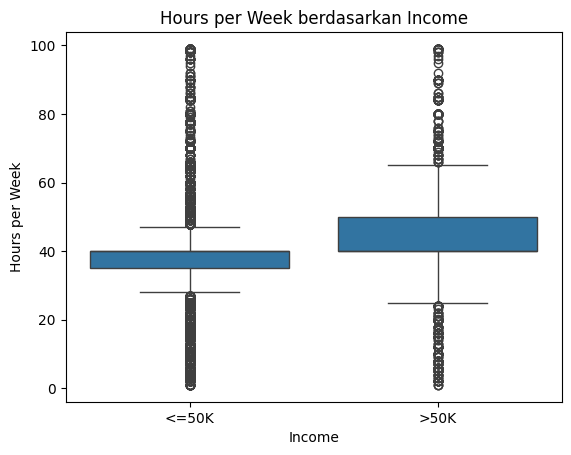

In [19]:
# Jawab 1.3 - Boxplot
plt.figure()
sns.boxplot(data=df, x='income', y='hours-per-week')
plt.title('Hours per Week berdasarkan Income')
plt.xlabel('Income')
plt.ylabel('Hours per Week')
plt.show()

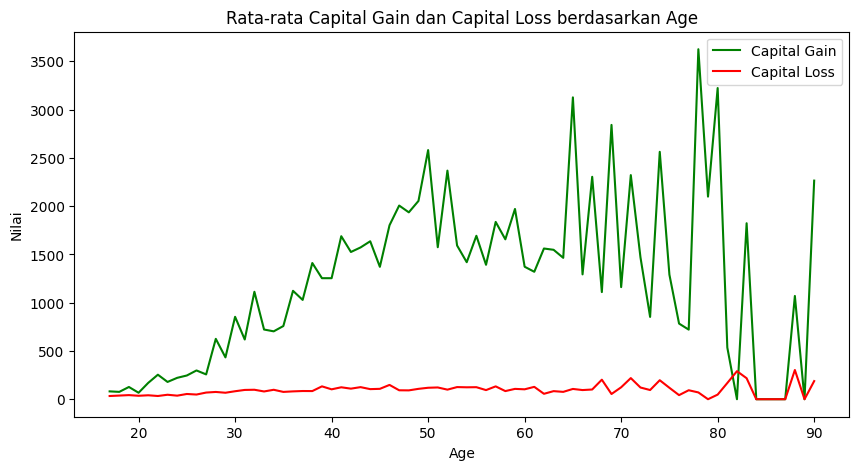

In [20]:
# Jawab 1.4 - Lineplot
rata_capital = df.groupby('age')[['capital-gain', 'capital-loss']].mean()

plt.figure(figsize=(10, 5))
plt.plot(rata_capital.index, rata_capital['capital-gain'], label='Capital Gain', color='green')
plt.plot(rata_capital.index, rata_capital['capital-loss'], label='Capital Loss', color='red')
plt.title('Rata-rata Capital Gain dan Capital Loss berdasarkan Age')
plt.xlabel('Age')
plt.ylabel('Nilai')
plt.legend()
plt.show()

## Soal 2 - Analisis Visual (15 poin)
1. Fenomena apa yang terjadi pada distribusi data 'age'?
2. Jika terdapat data yang hilang pada variabel 'age', strategi apa yang Anda terapkan? Mengapa?
3. Berapa jumlah outlier pada setiap kategori 'income' berkaitan dengan 'hour-per-week'? Kategori apa yang paling banyak memiliki outlier?

In [22]:
# Jawab dengan komentar python

'''
 1. Fenomena apa yang terjadi pada distribusi data 'age'? Karena Distribusi condong ke kanan.
    Mayoritas orang berada di usia produktif (20-40 tahun) dan semakin sedikit di usia tua.
 2. Jika terdapat data yang hilang pada variabel 'age', strategi apa yang Anda terapkan? Mengapa?
    Dilakukan imputasi menggunakan median. Karena datanya skewed dan ada nilai ekstrim,
    sehingga median lebih aman dan tidak terpengaruh outlier dibandingkan mean.
 3. Outlier 'hours-per-week' pada 'income':
   - Kategori '<=50K' memiliki lebih banyak outlier (sekitar 9.000-an).
   - Kategori '>50K' memiliki lebih sedikit outlier (sekitar 3.000-an).
   Kategori yang paling banyak memiliki outlier adalah '<=50K'.
'''

"\n 1. Fenomena apa yang terjadi pada distribusi data 'age'? Karena Distribusi condong ke kanan.\n    Mayoritas orang berada di usia produktif (20-40 tahun) dan semakin sedikit di usia tua.\n 2. Jika terdapat data yang hilang pada variabel 'age', strategi apa yang Anda terapkan? Mengapa?\n    Dilakukan imputasi menggunakan median. Karena datanya skewed dan ada nilai ekstrim,\n    sehingga median lebih aman dan tidak terpengaruh outlier dibandingkan mean.\n 3. Outlier 'hours-per-week' pada 'income':\n   - Kategori '<=50K' memiliki lebih banyak outlier (sekitar 9.000-an).\n   - Kategori '>50K' memiliki lebih sedikit outlier (sekitar 3.000-an).\n   Kategori yang paling banyak memiliki outlier adalah '<=50K'.\n"

# Bagian 3 - Encoding Variabel Kategorical

## Soal 1 (5 poin)
Lakukan encoding pada 'Sex' dan 'Income'. 'Income' merupakan variabel target

In [23]:
# Jawab Soal 1
# Kerjakan pada cell ini
from sklearn.preprocessing import LabelEncoder

label = LabelEncoder()

df['sex'] = label.fit_transform(df['sex'])
df['income'] = label.fit_transform(df['income'])


print(df[['sex', 'income']].head())

   sex  income
0    1       0
1    1       0
2    1       0
3    1       0
4    0       0


# Bagian 4 - Analisis Korelasi

## Soal 1 (10 poin)
1. Lakukan analisis korelasi pada variabel 'age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', dan 'income' (yang sudah di-encoding)
2. Berdasarkan hasil korelasi, informasi apa yang dapat Anda interpretasikan?

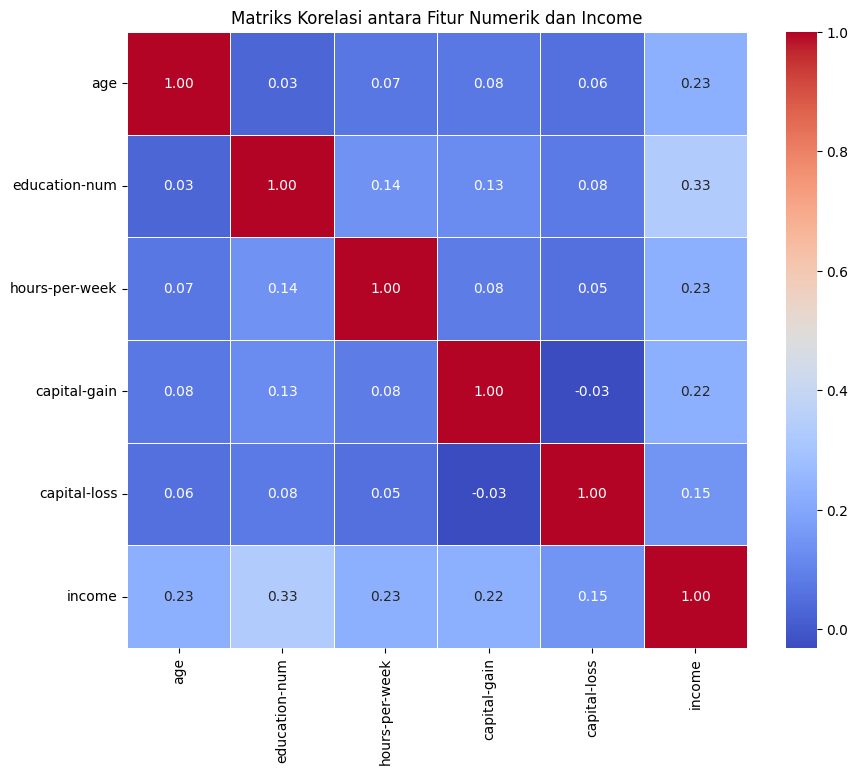

In [26]:
# Jawab Soal 1
# Kerjakan pada cell ini
kolom_korelasi = ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', 'income']

matriks_korelasi = df[kolom_korelasi].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriks_korelasi, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriks Korelasi antara Fitur Numerik dan Income')
plt.show()

In [ ]:
# Hasil analisis jelaskan pada cell ini
'''
Interpretasi Hasil Korelasi:

1. Pengaruh terhadap income:
   - fitur education-num memiliki korelasi positif tertinggi terhadap income (sekitar 0.33). Artinya, semakin tinggi tingkat pendidikan seseorang, semakin besar peluang pendapatannya di atas 50K (>50K).
   - fitur age (~0.23) dan fitur hours-per-week (~0.23) juga berkorelasi positif. Semakin matang usia dan semakin banyak jam kerja per minggu, potensi penghasilan cenderung ikut meningkat.
   - fitur capital-gain (~0.22) dan fitur capital-loss (~0.15) memiliki hubungan positif lebih rendah namun tetap searah dengan peningkatan income.

2. Hubungan Antar Fitur:
   - Nilai korelasi antar variabel bebas tergolong rendah (semuanya di bawah 0.4), sehingga tidak terjadi masalah multikolinearitas (tidak ada variabel yang saling tumpang tindih secara berlebihan).
'''

# Bagian 5 - Pra Pengolahan Data Pada Dataset MNIST

Pada bagian ini, Anda diminta untuk melakukan proses EDA dan pra pengolahan data sederhana pada dataset MNIST. Dataset MNIST merupakan data citra tulisan tangan untuk digil 0 hingga 9. Sebelum melakukan proses pengolahan, Anda akan dibantu dengan proses loading data dan inspeksi data.

Hints:
1. Hanya gunakan data **Test**
2. Anda perlu melakukan pengolahan terhadap semua data test (total 10k data). Anda dapat menggunakan function untuk mempermudah pekerjaan.

In [27]:
# Fetch data and inspect data shape
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load train & test split
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


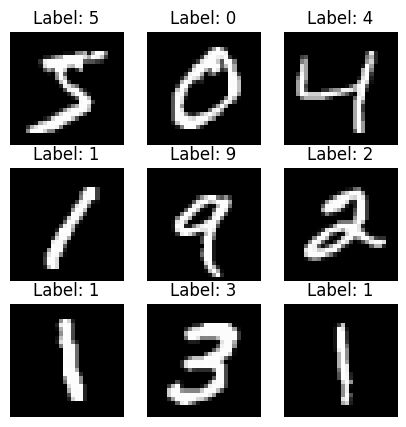

In [28]:
# Inspeksi Visual
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.show()

## Soal 1 (10 poin)
1. Lakukan proses **upsampling** citra menjadi ukuran 32x32
2. Tampilakan 5 data hasil proses **upsampling**

Hint: Anda harus membuat array kosong untuk menampung hasil upsampling. Replace pada array X_test tidak dapat dilakukan karena data disimpan dalam bentuk ndarray yang memiliki ukuran fix (10000, (28,28))

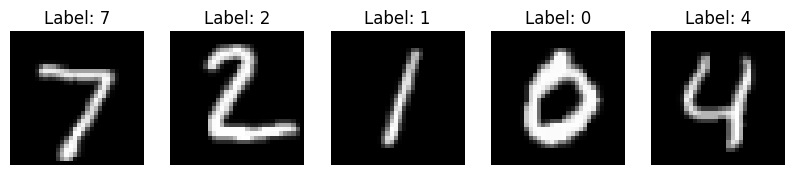

In [31]:
# Jawab Soal 1
# Kerjakan pada cell ini
import cv2

X_test_upsampled = np.zeros((len(X_test), 32, 32))

for i in range(len(X_test)):
    X_test_upsampled[i] = cv2.resize(X_test[i], (32, 32))

plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test_upsampled[i], cmap='gray')
    plt.title(f"Label: {y_test[i]}")
    plt.axis('off')
plt.show()


## Soal 2 (10 poin)
Lakukan normalisasi nilai citra tiap piksel menjadi rentang 0-1

In [32]:
# Jawab Soal 2
# Kerjakan pada cell ini
X_test_normalized = X_test_upsampled / 255.0

print("Nilai piksel minimum:", X_test_normalized.min())
print("Nilai piksel maksimum:", X_test_normalized.max())
print("Bentuk data:", X_test_normalized.shape)

Nilai piksel minimum: 0.0
Nilai piksel maksimum: 1.0
Bentuk data: (10000, 32, 32)


## Soal 3 (10 poin)
Ubah metriks citra menjadi array 1 dimensi. Lakukan pada semua data test yang sudah di resize dan normalisasi.

Hint: Anda harus membuat holder array kosong untuk menampung hasilnya.

In [34]:
# Jawab Soal 3
# Kerjakan pada cell ini
total_piksel = 32 * 32

X_test_flat = np.zeros((10000, total_piksel))

for i in range(10000):
    X_test_flat[i] = X_test_normalized[i].flatten()

print("Ukuran awal:", X_test_normalized.shape)
print("Ukuran setelah diubah ke 1D:", X_test_flat.shape)

Ukuran awal: (10000, 32, 32)
Ukuran setelah diubah ke 1D: (10000, 1024)
